# PIGNet (Physics-Informed GNN) 虚拟筛选教程

本 notebook 只保留 **物理能量分解回归亲和力** 这条技术路线。

统一约定：
- 骨架统一为 `nn.Linear() + nn.ReLU()`
- 训练输出统一展示 loss history
- 结果区只保留家族主指标 `Pearson R` 和 `RMSE`

In [24]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
from rdkit import Chem, RDLogger
from rdkit.Chem import rdMolDescriptors
import matplotlib.pyplot as plt

%matplotlib inline
warnings.filterwarnings("ignore")
RDLogger.DisableLog("rdApp.*")

# 定位项目根目录并设置 import 路径
_root = Path(".").resolve()
while not (_root / "demo_data").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

PROJECT_ROOT = _root
DATA_DIR = PROJECT_ROOT / "demo_data"
CORESET_FILE = DATA_DIR / "CoreSet.dat"
COMPLEX_DIR = DATA_DIR / "coreset"

from teaching_demos.common import (
    ATOM_FEAT_DIM, atom_features, build_mlp, describe_model_parameters,
    history_frame, load_complex, metric_frame, parse_coreset, plot_loss_curves,
)

## 1. 超参数设置

PIGNet 的核心创新是将结合自由能分解为物理可解释的分量：

| 参数 | 含义 | 说明 |
|------|------|------|
| `VDW_N` | LJ 势指数 | 标准 12-6 势 |
| `ATOM_FEAT_DIM` | 原子特征维度 | 10 维统一表征 |
| `HIDDEN_DIM` | 隐层维度 | 节点嵌入和能量分解 MLP |

In [25]:
# --- Lennard-Jones 势参数 ---
VDW_N = 6
MAX_VDW_INTERACTION = 0.0356
MIN_VDW_INTERACTION = 0.0178
DEV_VDW_RADIUS = 0.2

HIDDEN_DIM = 128
N_EPOCHS = 200
LR = 3e-4
BATCH_SIZE = 1
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 化学常量
SYMBOLS = ["C", "N", "O", "S", "F", "P", "Cl", "Br", "X"]
METALS = ["Zn", "Mn", "Co", "Mg", "Ni", "Fe", "Ca", "Cu"]
HYDROPHOBICS = ["F", "Cl", "Br", "I"]

VDWRADII = {
    6: 1.90, 7: 1.8, 8: 1.7, 16: 2.0, 15: 2.1, 9: 1.5, 17: 1.8,
    35: 2.0, 53: 2.2, 30: 1.2, 25: 1.2, 26: 1.2, 27: 1.2, 12: 1.2,
    28: 1.2, 20: 1.2, 29: 1.2,
}

HBOND_DONOR_INDICES = ["[!#6;!H0]"]
HBOND_ACCEPPTOR_SMARTS = ["[$([!#6;+0]);!$([F,Cl,Br,I]);!$([o,s,nX3]);!$([Nv5,Pv5,Sv4,Sv6])]"]

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"设备: {DEVICE}")
print(f"原子特征维度: {ATOM_FEAT_DIM}")
print(f"隐层维度: {HIDDEN_DIM}")
print(f"训练轮数: {N_EPOCHS}")

设备: cuda
原子特征维度: 10
隐层维度: 128
训练轮数: 200


## 2. 数据加载与特征提取

PIGNet 的特殊之处在于需要额外的物理化学特征：
- 范德华半径（用于 LJ 势计算）
- 氢键供体/受体矩阵
- 金属配位矩阵
- 疏水相互作用矩阵

In [26]:
def get_vdw_radius(atom):
    """获取原子的范德华半径。"""
    atomic_num = atom.GetAtomicNum()
    if atomic_num in VDWRADII:
        return VDWRADII[atomic_num]
    return Chem.GetPeriodicTable().GetRvdw(atomic_num)


def get_hbond_atom_indices(mol, smarts_list):
    """SMARTS 模式匹配氢键供体/受体原子索引。"""
    indices = []
    for smarts in smarts_list:
        pat = Chem.MolFromSmarts(smarts)
        matches = mol.GetSubstructMatches(pat)
        indices += [match[0] for match in matches]
    return np.array(indices, dtype=np.int64)


def get_hbond_matrix(lig_mol, prot_mol):
    """构建氢键相互作用矩阵 (N_lig x N_prot)。"""
    lig_acc = get_hbond_atom_indices(lig_mol, HBOND_ACCEPPTOR_SMARTS)
    prot_acc = get_hbond_atom_indices(prot_mol, HBOND_ACCEPPTOR_SMARTS)
    lig_don = get_hbond_atom_indices(lig_mol, HBOND_DONOR_INDICES)
    prot_don = get_hbond_atom_indices(prot_mol, HBOND_DONOR_INDICES)
    mat = np.zeros((lig_mol.GetNumAtoms(), prot_mol.GetNumAtoms()), dtype=np.float32)
    for i in lig_acc:
        for j in prot_don:
            mat[i, j] = 1.0
    for i in lig_don:
        for j in prot_acc:
            mat[i, j] = 1.0
    return mat


def get_metal_matrix(lig_mol, prot_mol):
    """构建金属配位矩阵：金属原子与对侧氢键受体配对。"""
    lig_acc = get_hbond_atom_indices(lig_mol, HBOND_ACCEPPTOR_SMARTS)
    prot_acc = get_hbond_atom_indices(prot_mol, HBOND_ACCEPPTOR_SMARTS)
    mat = np.zeros((lig_mol.GetNumAtoms(), prot_mol.GetNumAtoms()), dtype=np.float32)
    # 配体受体 <-> 蛋白金属
    for j, atom in enumerate(prot_mol.GetAtoms()):
        if atom.GetSymbol() in METALS:
            for i in lig_acc:
                mat[i, j] = 1.0
    # 配体金属 <-> 蛋白受体
    for i, atom in enumerate(lig_mol.GetAtoms()):
        if atom.GetSymbol() in METALS:
            for j in prot_acc:
                mat[i, j] = 1.0
    return mat


def get_hydrophobic_matrix(lig_mol, prot_mol):
    """构建疏水相互作用矩阵。"""
    def is_hydrophobic(a):
        sym = a.GetSymbol()
        if sym in HYDROPHOBICS:
            return True
        if sym == "C":
            return {x.GetSymbol() for x in a.GetNeighbors()} <= {"C"}
        return False
    lig_hydro = [is_hydrophobic(a) for a in lig_mol.GetAtoms()]
    prot_hydro = [is_hydrophobic(a) for a in prot_mol.GetAtoms()]
    mat = np.zeros((lig_mol.GetNumAtoms(), prot_mol.GetNumAtoms()), dtype=np.float32)
    for i, lh in enumerate(lig_hydro):
        for j, ph in enumerate(prot_hydro):
            if lh and ph:
                mat[i, j] = 1.0
    return mat


def load_complex_pignet(pdbid):
    """加载单个复合物并提取 PIGNet 所需的物理化学特征。"""
    cplx = load_complex(pdbid, COMPLEX_DIR)
    lig_mol, prot_mol = cplx["lig_mol"], cplx["prot_mol"]

    lig_feats = np.array([atom_features(a) for a in lig_mol.GetAtoms()], dtype=np.float32)
    prot_feats = np.array([atom_features(a) for a in prot_mol.GetAtoms()], dtype=np.float32)
    lig_vdw = np.array([get_vdw_radius(a) for a in lig_mol.GetAtoms()], dtype=np.float32)
    prot_vdw = np.array([get_vdw_radius(a) for a in prot_mol.GetAtoms()], dtype=np.float32)

    hbond_mat = get_hbond_matrix(lig_mol, prot_mol)
    metal_mat = get_metal_matrix(lig_mol, prot_mol)
    hydrophobic_mat = get_hydrophobic_matrix(lig_mol, prot_mol)

    lig_non_metal = np.array([0.0 if a.GetSymbol() in METALS else 1.0 for a in lig_mol.GetAtoms()], dtype=np.float32)
    prot_non_metal = np.array([0.0 if a.GetSymbol() in METALS else 1.0 for a in prot_mol.GetAtoms()], dtype=np.float32)
    rotor = float(Chem.rdMolDescriptors.CalcNumRotatableBonds(lig_mol))

    return {
        "lig_h": lig_feats, "prot_h": prot_feats,
        "lig_pos": cplx["lig_coords"], "prot_pos": cplx["prot_coords"],
        "lig_vdw": lig_vdw, "prot_vdw": prot_vdw,
        "hbond_mat": hbond_mat, "metal_mat": metal_mat,
        "hydrophobic_mat": hydrophobic_mat,
        "lig_non_metal": lig_non_metal, "prot_non_metal": prot_non_metal,
        "rotor": np.array([rotor], dtype=np.float32),
    }


labels = parse_coreset(CORESET_FILE)
print(f"从 CoreSet.dat 读取到 {len(labels)} 个复合物标签")

all_data = []
for pdbid, logka in sorted(labels.items()):
    sample = load_complex_pignet(pdbid)
    sample["label"] = logka
    all_data.append(sample)

print(f"成功加载 {len(all_data)} 个复合物")

从 CoreSet.dat 读取到 20 个复合物标签
成功加载 20 个复合物


In [27]:
s = all_data[0]
display(pd.DataFrame({
    '特征': [k for k in s if k != 'label'],
    '形状': [str(s[k].shape) if isinstance(s[k], np.ndarray) else str(s[k]) for k in s if k != 'label'],
}))

,特征,形状
0,lig_h,"(36, 10)"
1,prot_h,"(614, 10)"
2,lig_pos,"(36, 3)"
3,prot_pos,"(614, 3)"
4,lig_vdw,"(36,)"
5,prot_vdw,"(614,)"
6,hbond_mat,"(36, 614)"
7,metal_mat,"(36, 614)"
8,hydrophobic_mat,"(36, 614)"
9,lig_non_metal,"(36,)"


## 3. 数据集与数据加载器

封装为 PyTorch `Dataset`，80/20 随机划分。变长图逐样本处理。

In [28]:
from torch.utils.data import Dataset, DataLoader


class PIGNetDataset(Dataset):
    def __init__(self, data_list):
        self.data_list = data_list

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        d = self.data_list[idx]
        return {k: torch.tensor(v, dtype=torch.float32) for k, v in d.items()}


indices = np.random.permutation(len(all_data))
split = int(0.8 * len(all_data))
train_data = [all_data[i] for i in indices[:split]]
test_data = [all_data[i] for i in indices[split:]]

train_loader = DataLoader(PIGNetDataset(train_data), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(PIGNetDataset(test_data), batch_size=BATCH_SIZE, shuffle=False)

display(pd.DataFrame({
    '数据集': ['训练集', '测试集', '合计'],
    '样本数': [len(train_data), len(test_data), len(all_data)],
    '比例': [f'{len(train_data)/len(all_data):.0%}', f'{len(test_data)/len(all_data):.0%}', '100%']
}))

,数据集,样本数,比例
0,训练集,16,80%
1,测试集,4,20%
2,合计,20,100%


## 4. 模型架构

```
原子特征 → 节点嵌入 (build_mlp) → 原子对特征拼接
  → 学习参数 A, B (build_mlp + Sigmoid/Tanh)
  → 距离矩阵 dm + VDW半径 → dm_0 = lig_vdw + prot_vdw + B
  → Lennard-Jones 势 → E_vdw : A · [(dm_0/dm)^12 − 2·(dm_0/dm)^6]
  → 氢键距离函数  → E_hbond : clamp((dm−dm_0)/−0.7, 0, 1) · −(coeff²)
  → 金属配位      → E_metal : 同氢键公式，金属-受体掩码
  → 疏水接触函数  → E_hydro : clamp(−(dm−dm_0)+1.5, 0, 1) · −(coeff²)
  → 直接求和 E_total = E_vdw + E_hbond + E_metal + E_hydro
  → 旋转惩罚 → logKa = E_total / (1 + rotor_coeff² · rotor)
```

**核心创新：物理可解释的能量分解。** PIGNet 将结合自由能分解为 vdW、氢键、金属配位、疏水四个物理分量，每个分量由闭式物理公式计算，MLP 仅用于学习公式中的参数 A 和 B。

> 教学简化：原版使用 GatedGAT + InteractionNet 做图消息传递，本 notebook 统一使用 MLP 节点嵌入。

In [29]:
class PIGNetToyModel(nn.Module):
    """物理能量分解路线：MLP 学习参数 A/B，闭式物理公式计算能量。"""

    def __init__(self, atom_dim=ATOM_FEAT_DIM, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.node_embed = build_mlp(atom_dim, hidden_dim, hidden_dim)
        pair_dim = hidden_dim * 2
        # 学习 LJ 势的幅度参数 A（Sigmoid 保证 [0,1]）
        self.cal_vdw_A = nn.Sequential(
            *build_mlp(pair_dim, hidden_dim, 1), nn.Sigmoid()
        )
        # 学习距离偏移参数 B（Tanh 保证 [-1,1]，再乘 DEV_VDW_RADIUS）
        self.cal_vdw_B = nn.Sequential(
            *build_mlp(pair_dim, hidden_dim, 1), nn.Tanh()
        )
        # 可学习能量系数
        self.hbond_coeff = nn.Parameter(torch.tensor([1.0]))
        self.hydrophobic_coeff = nn.Parameter(torch.tensor([0.5]))
        self.rotor_coeff = nn.Parameter(torch.tensor([0.5]))

    def forward(self, sample):
        # --- 节点嵌入 ---
        lig_h = self.node_embed(sample["lig_h"])
        prot_h = self.node_embed(sample["prot_h"])

        # --- 距离矩阵 ---
        lig_pos = sample["lig_pos"]
        prot_pos = sample["prot_pos"]
        dm = torch.cdist(lig_pos.unsqueeze(0), prot_pos.unsqueeze(0)).squeeze(0)
        dm = dm.clamp(min=0.5)  # 防止数值奇异

        N_l, N_p = lig_h.size(0), prot_h.size(0)

        # --- VDW 半径展开为 (N_l, N_p) ---
        lig_vdw_r = sample["lig_vdw"].unsqueeze(1).expand(N_l, N_p)
        prot_vdw_r = sample["prot_vdw"].unsqueeze(0).expand(N_l, N_p)

        # --- 非金属掩码 ---
        non_metal_mask = sample["lig_non_metal"].unsqueeze(1) * sample["prot_non_metal"].unsqueeze(0)

        # --- 原子对特征拼接 ---
        lig_expand = lig_h.unsqueeze(1).expand(-1, N_p, -1)
        prot_expand = prot_h.unsqueeze(0).expand(N_l, -1, -1)
        h_cat = torch.cat([lig_expand, prot_expand], dim=-1)  # (N_l, N_p, 2*hidden)

        # --- 学习参数 A 和 B ---
        A_raw = self.cal_vdw_A(h_cat).squeeze(-1)  # (N_l, N_p)
        B = self.cal_vdw_B(h_cat).squeeze(-1) * DEV_VDW_RADIUS  # (N_l, N_p)

        # --- 平衡距离 dm_0 ---
        dm_0 = lig_vdw_r + prot_vdw_r + B
        dm_0 = dm_0.clamp(min=1e-4)

        # --- 距离掩码 (5 Å) ---
        mask = (dm < 5.0).float()

        # ===== 1. VDW 能量：Lennard-Jones 势 =====
        A_vdw = A_raw * (MAX_VDW_INTERACTION - MIN_VDW_INTERACTION) + MIN_VDW_INTERACTION
        vdw_term1 = torch.pow(dm_0 / dm, 2 * VDW_N)
        vdw_term2 = -2 * torch.pow(dm_0 / dm, VDW_N)
        vdw_energy = A_vdw * (vdw_term1 + vdw_term2).clamp(max=100)
        vdw_e = (vdw_energy * non_metal_mask * mask).sum()

        # ===== 2. 氢键能量 =====
        dm_diff = dm - dm_0
        hbond_e = ((dm_diff / -0.7).clamp(0, 1) * sample["hbond_mat"] * mask).sum()
        hbond_e = hbond_e * -(self.hbond_coeff ** 2)

        # ===== 3. 金属配位能量（同氢键公式） =====
        metal_e = ((dm_diff / -0.7).clamp(0, 1) * sample["metal_mat"] * mask).sum()
        metal_e = metal_e * -(self.hbond_coeff ** 2)

        # ===== 4. 疏水能量 =====
        hydro_e = ((-dm_diff + 1.5).clamp(0, 1) * sample["hydrophobic_mat"]).sum()
        hydro_e = hydro_e * -(self.hydrophobic_coeff ** 2)

        # --- 直接求和（物理可解释） ---
        energy = vdw_e + hbond_e + metal_e + hydro_e

        # --- 取反 + 旋转惩罚 ---
        # 结合能为负值（越负越稳定），取反后与正的 logKa 标签匹配
        pred = -energy / (1 + self.rotor_coeff ** 2 * sample["rotor"].float())
        return pred.squeeze()

In [30]:
model = PIGNetToyModel(atom_dim=ATOM_FEAT_DIM, hidden_dim=HIDDEN_DIM).to(DEVICE)
display(describe_model_parameters(model))

,层名称,形状,参数量
0,hbond_coeff,"(1,)",1
1,hydrophobic_coeff,"(1,)",1
2,rotor_coeff,"(1,)",1
3,node_embed.0.weight,"(128, 10)",1280
4,node_embed.0.bias,"(128,)",128
5,node_embed.2.weight,"(128, 128)",16384
6,node_embed.2.bias,"(128,)",128
7,cal_vdw_A.0.weight,"(128, 256)",32768
8,cal_vdw_A.0.bias,"(128,)",128
9,cal_vdw_A.2.weight,"(1, 128)",128


## 5. 训练

使用 **MSE Loss** 衡量预测 logKa 与实验值的差距。

In [31]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

train_loss_history = []
val_loss_history = []

print(f"开始训练 {N_EPOCHS} 轮...\n")

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    train_losses = []
    for batch in train_loader:
        sample = {k: v.squeeze(0).to(DEVICE) for k, v in batch.items()}
        label = sample.pop("label")
        pred = model(sample)
        loss = criterion(pred, label)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    val_losses = []
    with torch.no_grad():
        for batch in test_loader:
            sample = {k: v.squeeze(0).to(DEVICE) for k, v in batch.items()}
            label = sample.pop("label")
            pred = model(sample)
            val_losses.append(criterion(pred, label).item())

    train_loss_history.append(float(np.mean(train_losses)))
    val_loss_history.append(float(np.mean(val_losses)))
    if epoch == 1 or epoch % 20 == 0:
        print(f"Epoch {epoch:>3d}/{N_EPOCHS} | Train Loss: {train_loss_history[-1]:.4f} | Val Loss: {val_loss_history[-1]:.4f}")

history_df = history_frame(train_loss_history, val_loss_history)

开始训练 200 轮...

Epoch   1/200 | Train Loss: 15.4550 | Val Loss: 36.8485
Epoch  20/200 | Train Loss: 5.2578 | Val Loss: 11.9572
Epoch  40/200 | Train Loss: 4.7959 | Val Loss: 10.1109
Epoch  60/200 | Train Loss: 4.3635 | Val Loss: 9.0177
Epoch  80/200 | Train Loss: 3.6812 | Val Loss: 8.9476
Epoch 100/200 | Train Loss: 3.2795 | Val Loss: 7.0589
Epoch 120/200 | Train Loss: 3.0525 | Val Loss: 6.5405
Epoch 140/200 | Train Loss: 2.8091 | Val Loss: 6.2563
Epoch 160/200 | Train Loss: 2.5600 | Val Loss: 5.4285
Epoch 180/200 | Train Loss: 2.4235 | Val Loss: 4.9079
Epoch 200/200 | Train Loss: 2.3251 | Val Loss: 4.4374


## 6. 评估与可视化

- 统一展示训练的 loss history。
- 结果区只保留家族主指标：`Pearson R` 和 `RMSE`。

In [32]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        sample = {k: v.squeeze(0).to(DEVICE) for k, v in batch.items()}
        label = sample.pop("label")
        pred = model(sample)
        y_true.append(label.item())
        y_pred.append(pred.item())

y_true = np.asarray(y_true)
y_pred = np.asarray(y_pred)
r, _ = pearsonr(y_true, y_pred)
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))

display(metric_frame([("Pearson R", f"{r:.4f}"), ("RMSE", f"{rmse:.4f}")]))

,指标,值
0,Pearson R,0.5641
1,RMSE,2.1065


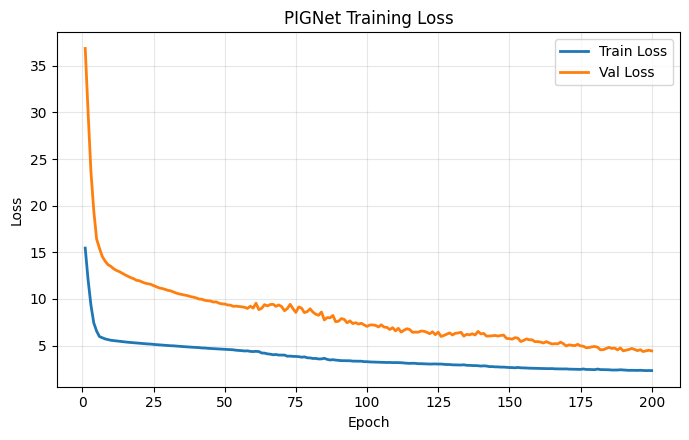

In [33]:
plot_loss_curves(train_loss_history, val_loss_history, title="PIGNet Training Loss")

## 总结

- 技术路线：物理能量分解（vdW + 氢键 + 金属 + 疏水）的亲和力回归。
- 教学骨架：`nn.Linear() + nn.ReLU()`。
- 主指标：`Pearson R` 和 `RMSE`。